In [1]:
import transformers
import torch
print(transformers.__version__) 
print(torch.__version__)

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


4.44.0
2.10.0+cu128


In [1]:
import os
import torch
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image

os.environ["TOKENIZERS_PARALLELISM"] = "false"
torch.set_num_threads(4)
torch.set_num_interop_threads(4)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cpu


In [2]:
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Florence-2-base",
    trust_remote_code=True,
    torch_dtype=torch.float32,
    attn_implementation="eager",
    _fast_init=False
).to(device)
model.eval()

processor = AutoProcessor.from_pretrained(
    "microsoft/Florence-2-base",
    trust_remote_code=True
)

print("✅ Modèle chargé")

✅ Modèle chargé


In [3]:
def run_florence(image_path, task):
    image = Image.open(image_path).convert("RGB")
    image.thumbnail((768, 768), Image.LANCZOS)
    
    inputs = processor(text=task, images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=512,
            num_beams=1,
            do_sample=False
        )
    
    result = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed = processor.post_process_generation(
        result,
        task=task,
        image_size=image.size
    )
    return parsed

In [6]:
image_path = "img_1767525774023-copy.png"

# Extraire tout le texte
print("=== OCR ===")
print(run_florence(image_path, "<OCR>"))

# Texte + positions
print("\n=== OCR WITH REGION ===")
print(run_florence(image_path, "<OCR_WITH_REGION>"))

# Détection d'objets
print("\n=== OBJECT DETECTION ===")
print(run_florence(image_path, "<OD>"))

=== OCR ===
{'<OCR>': 'SAPEnter Vendor Invoice: Company Code TALAVTree onCompany Code HoldSimulate | Park | Editing optionsCancelTransactnInvoiceBal.0.00Basic dataPaymentDetailsTaxNotesVendorGGL IndInvoice dateReferencePosting Date05.01.2026Cross-CC no.AmountMADCalculate taxTax amountTextCompany CodeTALA TALA SA CasablancaLot No.0 Items ( No entry variant selected)St. GIL acctShort TextDICAmount in docur.LoccurramountT. Tax jurisdiction codeW AssignmentDebit v0.000Debit 0.000.00Debit0.0001.00'}

=== OCR WITH REGION ===
{'<OCR_WITH_REGION>': {'quad_boxes': [[41.0880012512207, 5.124000072479248, 71.80799865722656, 5.124000072479248, 71.80799865722656, 20.739999771118164, 41.0880012512207, 20.739999771118164], [422.78399658203125, 9.515999794006348, 639.3599853515625, 9.515999794006348, 639.3599853515625, 22.691999435424805, 422.78399658203125, 22.691999435424805], [136.32000732421875, 43.67599868774414, 147.83999633789062, 43.67599868774414, 147.83999633789062, 51.97200012207031, 136.320

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:615: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:615: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


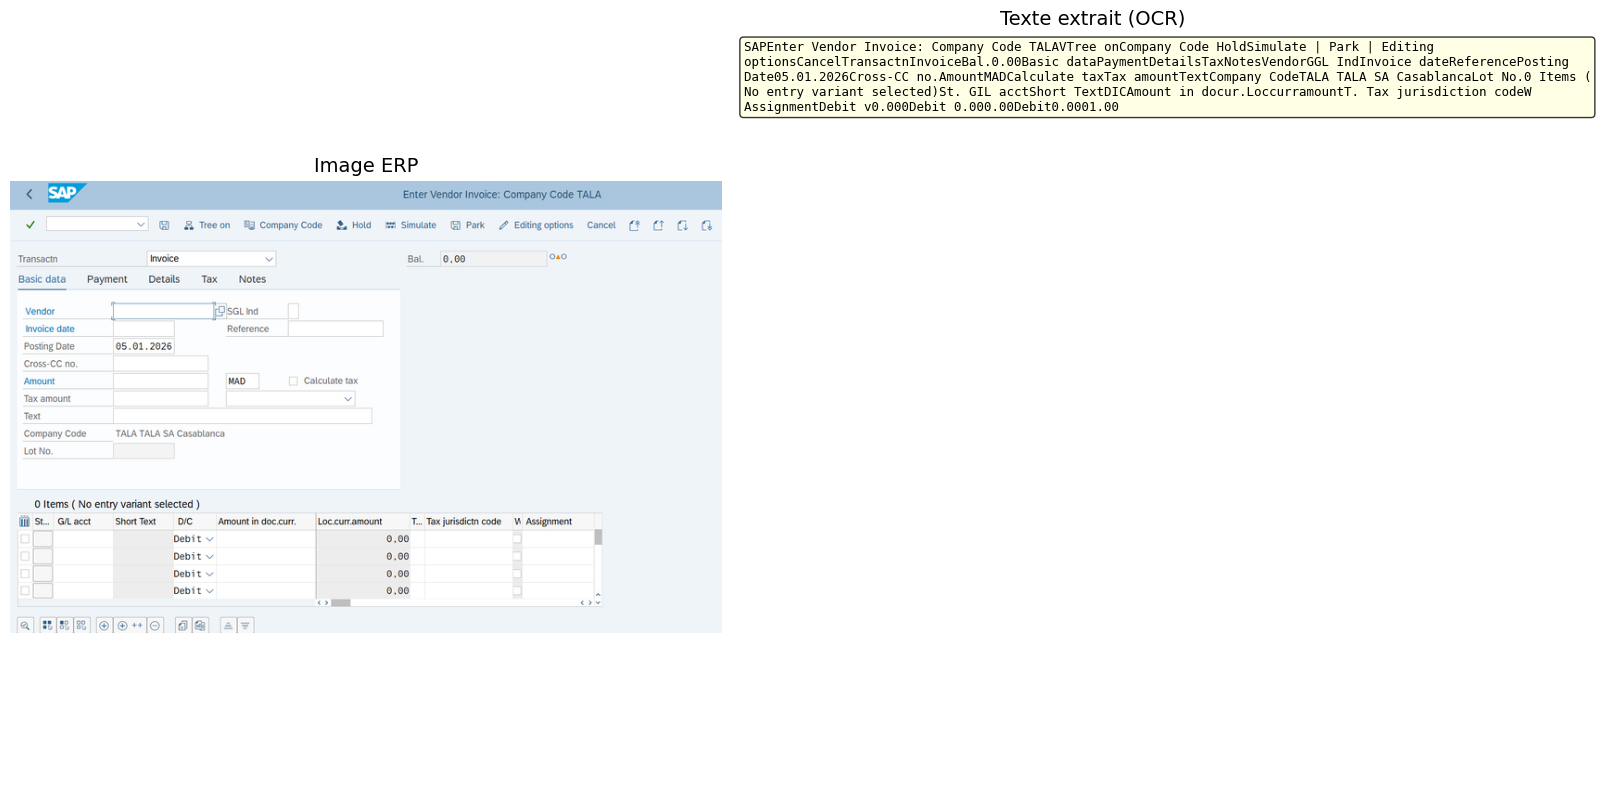


📄 Texte brut extrait :
SAPEnter Vendor Invoice: Company Code TALAVTree onCompany Code HoldSimulate | Park | Editing optionsCancelTransactnInvoiceBal.0.00Basic dataPaymentDetailsTaxNotesVendorGGL IndInvoice dateReferencePosting Date05.01.2026Cross-CC no.AmountMADCalculate taxTax amountTextCompany CodeTALA TALA SA CasablancaLot No.0 Items ( No entry variant selected)St. GIL acctShort TextDICAmount in docur.LoccurramountT. Tax jurisdiction codeW AssignmentDebit v0.000Debit 0.000.00Debit0.0001.00


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize_ocr(image_path):
    # 1. Lancer Florence-2
    image = Image.open(image_path).convert("RGB")
    image.thumbnail((768, 768), Image.LANCZOS)
    
    result = run_florence(image_path, "<OCR>")
    texte = result["<OCR>"]
    
    # 2. Afficher l'image + le texte extrait côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Image originale
    axes[0].imshow(image)
    axes[0].set_title("Image ERP", fontsize=14)
    axes[0].axis("off")
    
    # Texte extrait
    axes[1].axis("off")
    axes[1].set_title("Texte extrait (OCR)", fontsize=14)
    axes[1].text(
        0.01, 0.99, texte,
        transform=axes[1].transAxes,
        fontsize=9,
        verticalalignment="top",
        fontfamily="monospace",
        wrap=True,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8)
    )
    
    plt.tight_layout()
    plt.savefig("resultat_ocr.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print("\n📄 Texte brut extrait :")
    print("="*50)
    print(texte)
    
    return texte

# Lancer — remplace par ton chemin
texte = visualize_ocr("img_1767525774023-copy.png")

✅ 46 zones de texte détectées


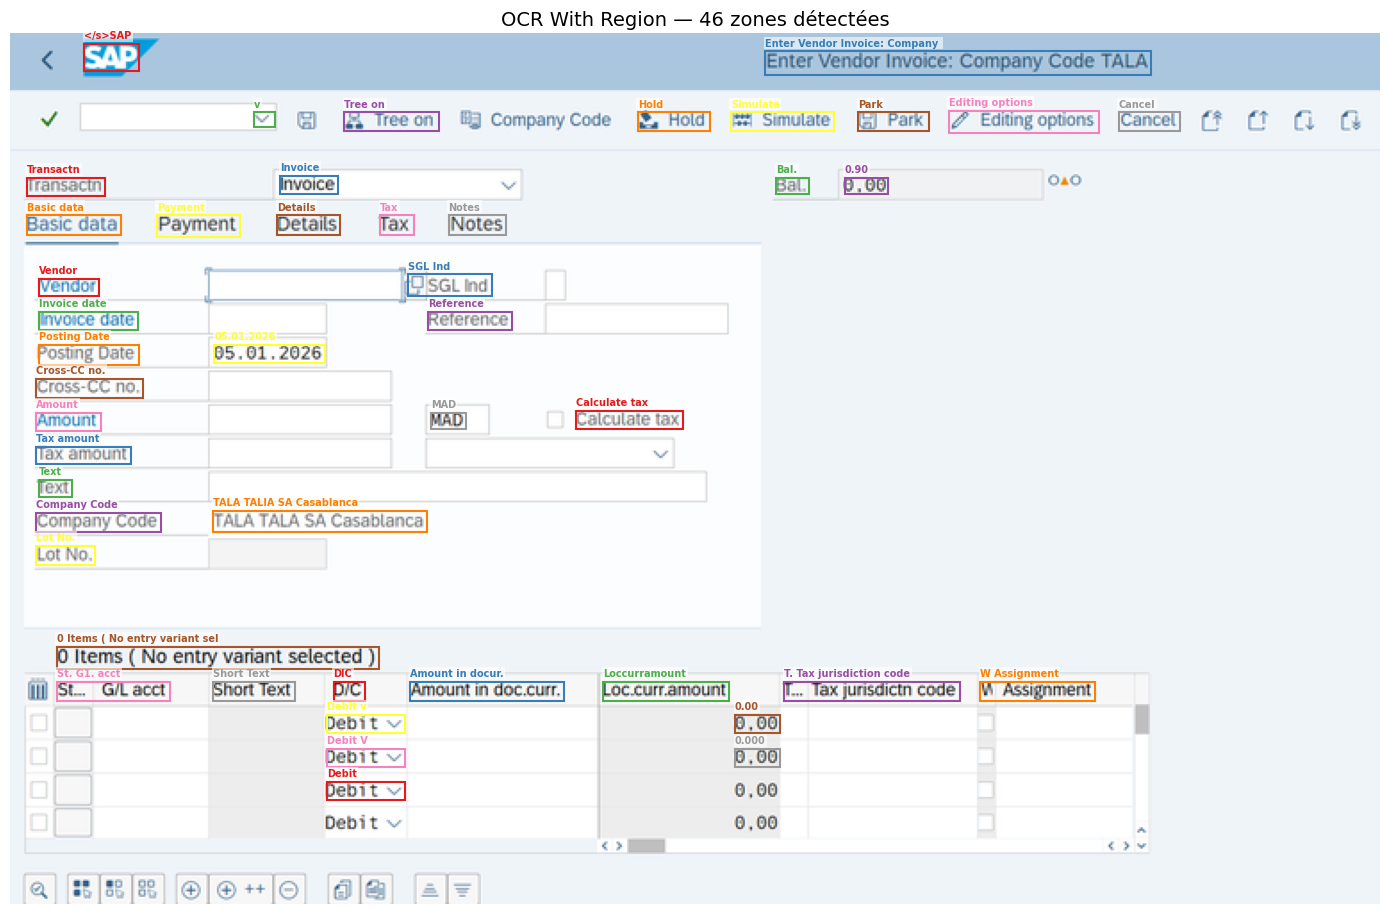


📄 Détail des zones :
[01] </s>SAP                                            | pos: (41,5)
[02] Enter Vendor Invoice: Company Code TALA            | pos: (423,10)
[03] v                                                  | pos: (136,44)
[04] Tree on                                            | pos: (187,44)
[05] Hold                                               | pos: (351,44)
[06] Simulate                                           | pos: (404,44)
[07] Park                                               | pos: (475,44)
[08] Editing options                                    | pos: (526,43)
[09] Cancel                                             | pos: (621,44)
[10] Transactn                                          | pos: (9,80)
[11] Invoice                                            | pos: (151,79)
[12] Bal.                                               | pos: (429,80)
[13] 0.90                                               | pos: (467,80)
[14] Basic data                               

In [8]:
def visualize_ocr_with_region(image_path):
    # 1. Lancer Florence-2
    image = Image.open(image_path).convert("RGB")
    image.thumbnail((768, 768), Image.LANCZOS)
    
    result = run_florence(image_path, "<OCR_WITH_REGION>")
    data = result["<OCR_WITH_REGION>"]
    
    texts  = data.get("labels", [])
    bboxes = data.get("quad_boxes", [])  # format [x1,y1,x2,y2,x3,y3,x4,y4]
    
    print(f"✅ {len(texts)} zones de texte détectées")
    
    # 2. Visualisation
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.imshow(image)
    ax.set_title(f"OCR With Region — {len(texts)} zones détectées", fontsize=14)
    ax.axis("off")
    
    # Palette de couleurs pour distinguer les zones
    colors = plt.cm.Set1.colors
    
    for i, (text, bbox) in enumerate(zip(texts, bboxes)):
        color = colors[i % len(colors)]
        
        # bbox format quad : [x1,y1, x2,y2, x3,y3, x4,y4]
        # On prend juste les coins pour dessiner un rectangle
        xs = bbox[0::2]  # x1, x2, x3, x4
        ys = bbox[1::2]  # y1, y2, y3, y4
        
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        
        # Rectangle
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=1.5,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)
        
        # Label texte au-dessus du rectangle
        ax.text(
            x_min, y_min - 3,
            text[:30],  # tronquer si trop long
            color=color,
            fontsize=7,
            fontweight="bold",
            bbox=dict(facecolor="white", alpha=0.6, pad=1, edgecolor="none")
        )
    
    plt.tight_layout()
    plt.savefig("resultat_ocr_region.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # 3. Résumé dans la console
    print("\n📄 Détail des zones :")
    print("="*60)
    for i, (text, bbox) in enumerate(zip(texts, bboxes)):
        xs = bbox[0::2]
        ys = bbox[1::2]
        print(f"[{i+1:02d}] {text[:50]:50s} | pos: ({min(xs):.0f},{min(ys):.0f})")
    
    return texts, bboxes

# Lancer
texts, bboxes = visualize_ocr_with_region("img_1767525774023-copy.png")

✅ 1 objets détectés

📊 Objets détectés :
  computer monitor     : 1x


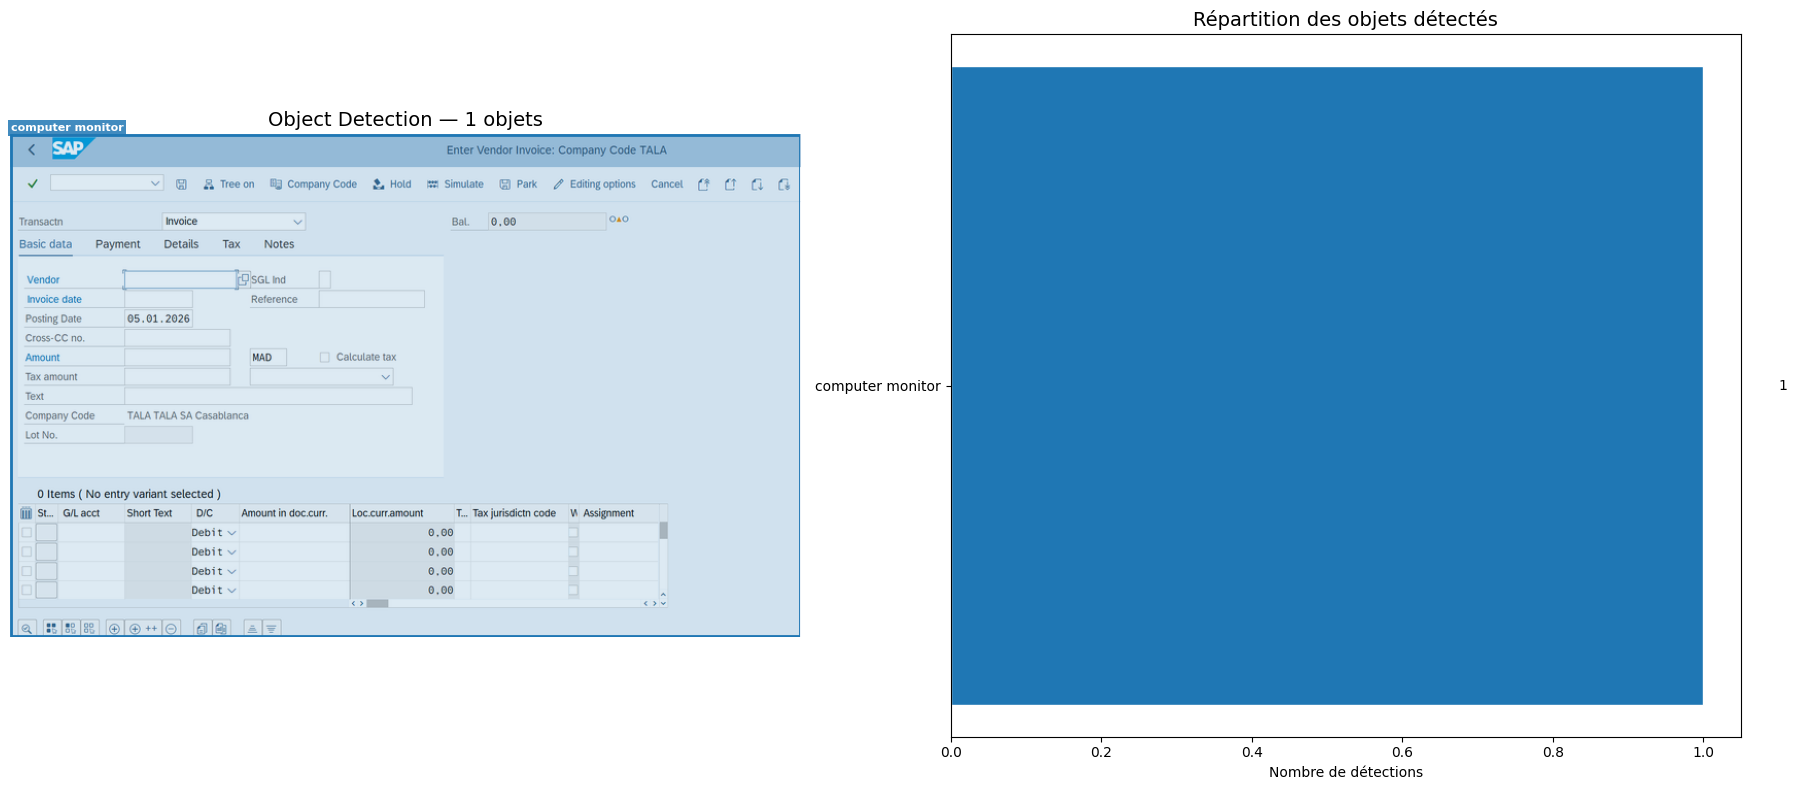


📄 Détail des détections :
[01] computer monitor     | bbox: (0,0) → (767,487)


In [9]:
def visualize_od(image_path):
    # 1. Lancer Florence-2
    image = Image.open(image_path).convert("RGB")
    image.thumbnail((768, 768), Image.LANCZOS)
    
    result = run_florence(image_path, "<OD>")
    data = result["<OD>"]
    
    labels = data.get("labels", [])
    bboxes = data.get("bboxes", [])  # format [x1, y1, x2, y2]
    
    print(f"✅ {len(labels)} objets détectés")
    
    # 2. Compter les occurrences par label
    from collections import Counter
    counts = Counter(labels)
    print("\n📊 Objets détectés :")
    for label, count in counts.most_common():
        print(f"  {label:20s} : {count}x")
    
    # 3. Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # -- Gauche : image annotée --
    axes[0].imshow(image)
    axes[0].set_title(f"Object Detection — {len(labels)} objets", fontsize=14)
    axes[0].axis("off")
    
    # Couleur unique par type de label
    unique_labels = list(set(labels))
    color_map = {
        label: plt.cm.tab20.colors[i % 20]
        for i, label in enumerate(unique_labels)
    }
    
    for label, bbox in zip(labels, bboxes):
        x1, y1, x2, y2 = bbox
        color = color_map[label]
        
        # Rectangle
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor=color,
            facecolor=color,
            alpha=0.15
        )
        axes[0].add_patch(rect)
        
        # Bordure nette
        rect_border = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor=color,
            facecolor="none"
        )
        axes[0].add_patch(rect_border)
        
        # Label
        axes[0].text(
            x1, y1 - 4,
            label,
            color="white",
            fontsize=8,
            fontweight="bold",
            bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor="none")
        )
    
    # -- Droite : histogramme des labels --
    axes[1].set_title("Répartition des objets détectés", fontsize=14)
    label_names = list(counts.keys())
    label_counts = list(counts.values())
    bar_colors = [color_map[l] for l in label_names]
    
    bars = axes[1].barh(label_names, label_counts, color=bar_colors, edgecolor="white")
    axes[1].set_xlabel("Nombre de détections")
    axes[1].invert_yaxis()
    
    # Ajouter les valeurs sur les barres
    for bar, count in zip(bars, label_counts):
        axes[1].text(
            bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            str(count),
            va="center",
            fontsize=10
        )
    
    plt.tight_layout()
    plt.savefig("resultat_od.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # 4. Résumé console
    print("\n📄 Détail des détections :")
    print("="*60)
    for i, (label, bbox) in enumerate(zip(labels, bboxes)):
        x1, y1, x2, y2 = bbox
        print(f"[{i+1:02d}] {label:20s} | bbox: ({x1:.0f},{y1:.0f}) → ({x2:.0f},{y2:.0f})")
    
    return labels, bboxes

# Lancer
labels, bboxes = visualize_od("img_1767525774023-copy.png")